<a href="https://colab.research.google.com/github/popdarin/Final-repo/blob/master/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
%%writefile going_modular/utils.py
import torch
import os

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from sklearn.metrics import confusion_matrix
from typing import List

def save_model(
    model: torch.nn.Module,
    target_dir: str,
    model_name: str
):
    """
    Saves a PyTorch model to a target directory.

    Args:
        model (torch.nn.Module): The PyTorch model to save.
        target_dir (str): The directory to save the model to.
        model_name (str): The name of the model file.

    Example usage:
        save_model(model=model_0,
                   target_dir="models",
                   model_name="05_going_modular_tingvgg_model.pth")
    """
    # Create target directory if it doesn't exist
    target_dir_path = Path(target_dir)
    target_dir_path.mkdir(parents=True, exist_ok=True)

    # Create model save path
    assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pth' or '.pt'"
    model_save_path = target_dir_path / model_name

    # Save the model state_dict()
    print(f"[INFO] Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(), f=model_save_path)

def make_confusion_matrix(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    class_names: List[str],
    device: torch.device
):
    """
    Generates and plots a confusion matrix for a given model and DataLoader.

    Args:
        model (torch.nn.Module): The PyTorch model to evaluate.
        dataloader (torch.utils.data.DataLoader): The DataLoader containing the data for evaluation.
        class_names (List[str]): A list of class names.
        device (torch.device): The device (CPU or GPU) to run the evaluation on.
    """
    model.eval()
    y_preds = []
    y_true = []

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_logits = model(X)
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
            y_preds.append(y_pred.cpu().numpy())
            y_true.append(y.cpu().numpy())

    y_preds = np.concatenate(y_preds)
    y_true = np.concatenate(y_true)

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_preds)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


Overwriting going_modular/utils.py


In [19]:
%%writefile going_modular/engine.py
import torch
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    return test_loss / len(dataloader), test_acc / len(dataloader)

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          writer: SummaryWriter):

    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model, dataloader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, device=device)
        test_loss, test_acc = test_step(model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)

        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        writer.add_scalars(main_tag="Loss", tag_scalar_dict={"train_loss": train_loss, "test_loss": test_loss}, global_step=epoch)
        writer.add_scalars(main_tag="Accuracy", tag_scalar_dict={"train_acc": train_acc, "test_acc": test_acc}, global_step=epoch)

    writer.close()
    return results

Overwriting going_modular/engine.py


In [4]:
%%writefile going_modular/model_builder.py
import torch
from torch import nn
import torchvision

class TinyVGG(nn.Module):
    """
    Creates the TinyVGG architecture.
    Replicates the TinyVGG architecture from the CNN explainer website in PyTorch.
    See the original architecture here: https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features come from?
            # It's because the first convolution layer has input_shape=3, output_channels=10.
            # The second layer still uses input_channels=10, output_channels=10.
            # After two blocks, the image size becomes 52x52. 52*52*10 = 27040
            # Try uncommenting the next line and passing a sample image through the network
            # print(f"Shape before Linear layer: {x.shape}")
            nn.Linear(in_features=27040,       # 10 features * 52 * 52 (from 224x224 -> 52x52)
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

def create_model(num_classes: int):
    """
    Creates an EfficientNetB0 feature extractor model and transforms.

    Args:
        num_classes (int): Number of classes in the dataset.

    Returns:
        Tuple (model, manual_transforms):
            - model (torch.nn.Module): An EffNetB0 feature extractor model.
            - manual_transforms (torchvision.transforms.Compose): Transforms to be applied to images.
    """

    # 1. Get the pre-trained weights for EfficientNet_B0
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

    # 2. Setup the EfficientNet_B0 model with its weights
    model = torchvision.models.efficientnet_b0(weights=weights)

    # 3. Freeze all base layers in the model
    for param in model.features.parameters():
        param.requires_grad = False

    # 4. Change the classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features=1280,
                  out_features=num_classes)
    )
    return model


Writing going_modular/model_builder.py


In [3]:
%%writefile going_modular/data_setup.py
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size: int,
    num_workers: int = NUM_WORKERS
):
    """
    Creates training and testing DataLoaders.

    Turns a target directory of images into Pytorch Datasets and then into PyTorch DataLoaders.

    Args:
        train_dir (str): Path to training directory.
        test_dir (str): Path to testing directory.
        transform (transforms.Compose): torchvision Transforms to perform on training and testing data.
        batch_size (int): Number of samples per batch in each DataLoader.
        num_workers (int, optional): Number of workers per DataLoader. Defaults to NUM_WORKERS.

    Returns:
        Tuple (train_dataloader, test_dataloader, class_names):
            - train_dataloader (torch.utils.data.DataLoader): Training DataLoader.
            - test_dataloader (torch.utils.data.DataLoader): Testing DataLoader.
            - class_names (list): List of target classes.
    """

    # Use ImageFolder to create dataset(s)
    train_data = datasets.ImageFolder(train_dir, transform=transform)
    test_data = datasets.ImageFolder(test_dir, transform=transform)

    # Get class names
    class_names = train_data.classes

    # Turn images into DataLoaders
    train_dataloader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    test_dataloader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_dataloader, test_dataloader, class_names


Writing going_modular/data_setup.py


In [20]:
import importlib

# Reload the modules to ensure the latest changes are loaded
importlib.reload(data_setup)
importlib.reload(model_builder)
importlib.reload(engine)
importlib.reload(utils)

print("[INFO] Reloaded going_modular modules.")

[INFO] Reloaded going_modular modules.


In [2]:
import os
os.makedirs("going_modular", exist_ok=True)

In [1]:
import zipfile
import os

zip_file_path = '/content/Final Project.zip'
output_dir = '/content/Final Project'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"'{zip_file_path}' unzipped to '{output_dir}'")


'/content/Final Project.zip' unzipped to '/content/Final Project'


[INFO] Using device: cuda
[INFO] Class names: ['class_a', 'class_b', 'class_c']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]


[INFO] Starting training for 10 epochs...


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9905 | train_acc: 0.6667 | test_loss: 1.1266 | test_acc: 0.0000
Epoch: 2 | train_loss: 0.9214 | train_acc: 0.6667 | test_loss: 0.9939 | test_acc: 0.6667
Epoch: 3 | train_loss: 0.8321 | train_acc: 1.0000 | test_loss: 0.9942 | test_acc: 0.6667
Epoch: 4 | train_loss: 0.6361 | train_acc: 1.0000 | test_loss: 0.8929 | test_acc: 0.6667
Epoch: 5 | train_loss: 0.6021 | train_acc: 1.0000 | test_loss: 0.8587 | test_acc: 0.6667
Epoch: 6 | train_loss: 0.5454 | train_acc: 1.0000 | test_loss: 0.7680 | test_acc: 0.6667
Epoch: 7 | train_loss: 0.4522 | train_acc: 1.0000 | test_loss: 0.7635 | test_acc: 0.6667
Epoch: 8 | train_loss: 0.3587 | train_acc: 1.0000 | test_loss: 0.7131 | test_acc: 0.6667
Epoch: 9 | train_loss: 0.2980 | train_acc: 1.0000 | test_loss: 0.6128 | test_acc: 0.6667
Epoch: 10 | train_loss: 0.2541 | train_acc: 1.0000 | test_loss: 0.6236 | test_acc: 0.6667
[INFO] Saving model to: models/ecommerce_product_model.pth
[INFO] Creating Confusion Matrix...


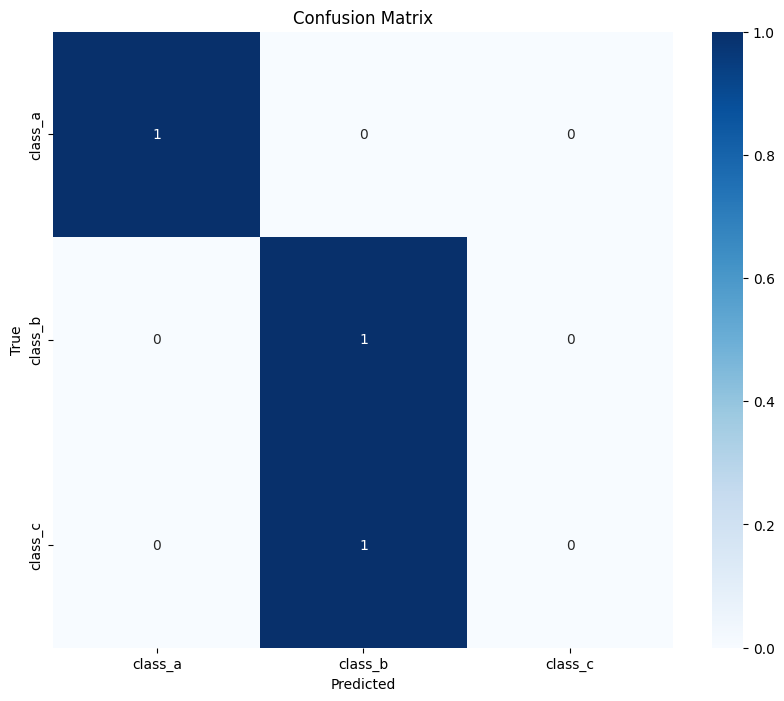

[INFO] Done!


In [26]:
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

# Import Modular
from going_modular import data_setup, model_builder, engine, utils

# Setup
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
TRAIN_DIR = "/content/Final Project/Final Project/train"
TEST_DIR = "/content/Final Project/Final Project/test"

# Setup device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")

# 1 Setup Transforms of Augmentation
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    normalize
])

# 2 สร้าง DataLoaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=TRAIN_DIR,
    test_dir=TEST_DIR,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)
print(f"[INFO] Class names: {class_names}")

# 3 สร้างโมเดล Transfer Learning
model = model_builder.create_model(num_classes=len(class_names)).to(device)

# 4 Setup Loss และ Optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

# 5 Setup TensorBoard
writer = SummaryWriter()

# 6 เริ่มการฝึกฝน
print(f"[INFO] Starting training for {EPOCHS} epochs...")
engine.train(model=model,
             train_dataloader=train_dataloader,
             test_dataloader=test_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             epochs=EPOCHS,
             device=device,
             writer=writer)

# 7 บันทึกโมเดล
utils.save_model(model=model,
                 target_dir="models",
                 model_name="ecommerce_product_model.pth")

# 8 สร้าง Confusion Matrix
print("[INFO] Creating Confusion Matrix...")
utils.make_confusion_matrix(model=model,
                           dataloader=test_dataloader,
                           class_names=class_names,
                           device=device)

print("[INFO] Done!")

In [10]:
with open('/content/going_modular/data_setup.py', 'r') as f:
    print(f.read())

In [15]:
%%writefile going_modular/data_setup.py
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count() or 4

def create_dataloaders(train_dir: str, test_dir: str, transform: transforms.Compose, batch_size: int, num_workers: int=NUM_WORKERS):
    # สร้าง dataset จาก ImageFolder
    train_data = datasets.ImageFolder(train_dir, transform=transform)
    test_data = datasets.ImageFolder(test_dir, transform=transform)

    # ดึงชื่อคลาส
    class_names = train_data.classes

    # สร้าง DataLoaders
    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                                  num_workers=num_workers, pin_memory=True)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)

    return train_dataloader, test_dataloader, class_names

Overwriting going_modular/data_setup.py


In [28]:
import importlib
from going_modular import data_setup, model_builder, engine, utils

importlib.reload(data_setup)
importlib.reload(model_builder)
importlib.reload(engine)
importlib.reload(utils)

print("[INFO] Modules reloaded successfully!")

[INFO] Modules reloaded successfully!
